# 1. Notebook kernel setup

After cloning repository at https://github.com/EstebanRivera08/PySonoGen, and the uv package, go on terminal to the location of the repository and run the following command to install the required packages:

`` uv run pycalib ``

To run these jupyter notebooks, the .venv environment of the project must be used as kernel.
To do so, from the repository path, you can run.

`` uv run -m ipykernel install --user --name=.venv --display-name "PySonoGen (.venv)" ``

This will create a jupyter kernel named 'PySonoGen (.venv)', that one can then select as kernel
of the notebook.


In [1]:
!where python

c:\Users\INSERM\Documents\Esteban\PySonoGen\.venv\Scripts\python.exe
C:\Users\INSERM\AppData\Local\Microsoft\WindowsApps\python.exe


In [2]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# 2. PySonoGen

## 2.1. Create Transducer

In [3]:
import pysonogen.transducers as Transducers
import numpy as np

In [4]:
print(Transducers.available_transducers())

['LinearArrayTransducer', 'MatrixArrayTransducer', 'Domino', 'Zeus_Matrix']


In [5]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz


domino = Transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
)

print(domino)


LinearArrayTransducer initialized in 0.0100 seconds.
LinearArrayTransducer(n_elements=128, el_w_mm=0.108, el_h_mm=1.5, kerf_mm=0.002000000000000002, elev_focus_mm=8.0, no_sub_x=1, no_sub_y=10, fc_Hz=12500000.0, Apod type=None, tx_N_active=128, F_over_D=None)


In [6]:
# Focalization spot
focus_mm =  np.array([2.3, 0, 6.5])  # mm [x, y, z]

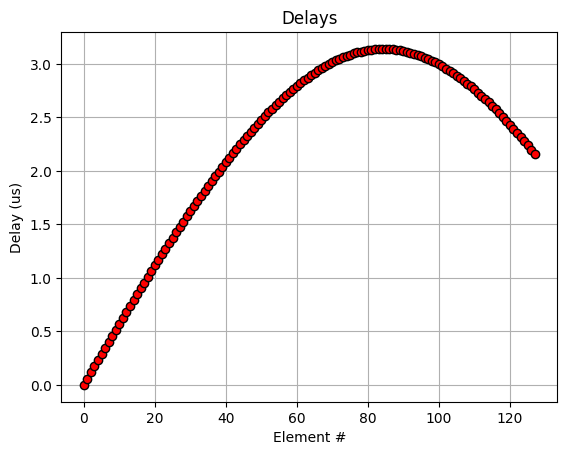

In [7]:
delays = domino.compute_delays(focus_mm = focus_mm, plot = True)

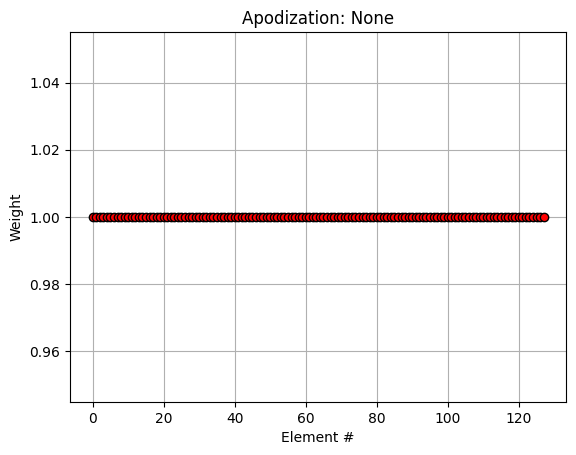

In [8]:
apodization = domino.compute_apodization(focus_mm = focus_mm, F_over_D = 1, apodization_type='rect', plot = True)

In [9]:
domino.set_apodization(apodization)
domino.set_delays(delays)
domino.show()  # Add this parameter

## 2.2. Compute Pressure Field

In [10]:
from pysonogen import pyfield

In [11]:
Domino_field = pyfield.PyField(domino)


In [12]:
field_info_mm = {
    "x_extent" : [-0.25+focus_mm[0], 0.25+focus_mm[0]],
    "y_extent" : [-0.5+focus_mm[1], 0.5+focus_mm[1]],
    "z_extent" : [-1+focus_mm[2], 1+focus_mm[2]],
    "dx" : 0.0125,
    "dy" : 0.025,
    "dz" : 0.05,
}

In [13]:
pressure_field, x, y, z = Domino_field.compute_pressure_field(field_info_mm)

Computing SIR for 68921 points and 1280 patches...
Events patch - field points computed in: 0.9167 seconds.
Accumulation of events elapsed in: 16.2208 seconds.
Looking for fc: 12500000.0 Hz, found : 12328767.123287672 Hz, in 0.39 seconds.
Pressure field computed in: 1755854336.0000 seconds.


## 2.3. Visualize pressure field

In [14]:
import pysonogen

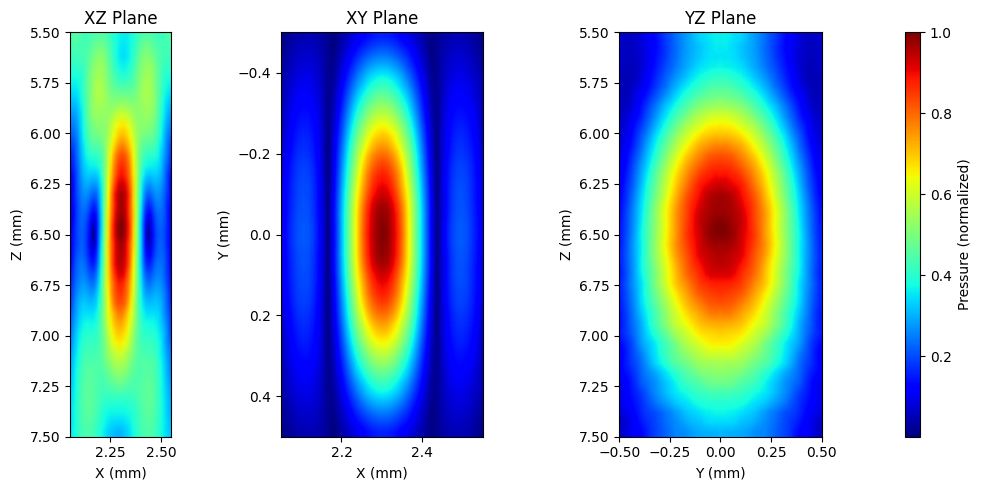

In [15]:
pysonogen.plot_field_planes(pressure_field,
                               x, y, z, figsize = (10, 5), interpolation="bilinear")

One can use customized functions for visualization

In [16]:
def add_transducer_to_plotter(plotter, TX_mesh):
    # Add the transducer to the plotter# 2) Add your TX_mesh with Apodization 
    plotter.add_mesh(TX_mesh, 
        scalars="Apodization",     # use the attached scalar
        cmap="cool",             # color map (you can change to "plasma", "coolwarm", etc.)
        show_scalar_bar=True,
        scalar_bar_args={
            "title": "Apodization",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.6,
            "height": 0.3,
        },
        label ="Transducer",  # label for the legend
        color = "purple", # color of the mesh
    )
    return plotter

def add_pressure_to_plotter(plotter, pressure_vol, plot_focal_spot = True):
    # 3) Add the pressure volume
    if plot_focal_spot:
        # pick a threshold, e.g. halfway to the max
        threshold = 0.7 * pressure_field.max()
        iso_mesh = pressure_vol.contour([threshold], scalars="Pressure")  # Create isosurface at threshold# add that instead of (or in addition to) the volume
        plotter.add_mesh(
            iso_mesh,
            opacity=1.0,
            name="PressureIso",
            show_scalar_bar=False,
            label="Focal Spot",
            color = "r", # color of the mesh
        )
    else:
        n_contours = 10
        min_val = 0
        max_val = pressure_field.max()
        levels = np.linspace(min_val, max_val, n_contours)
        iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
        plotter.add_mesh(
            iso_mesh,
            scalars="Pressure",  # use the scalar to color surfaces
            cmap="jet",                   # color map
            opacity='linear',                  # solid surfaces
            show_scalar_bar=True,
            scalar_bar_args={"title": "Pressure",
                "vertical": True,
                "title_font_size": 16,
                "label_font_size": 12,
                "position_x": 0.9,
                "position_y": 0.2,
                "height": 0.3,
            },
            label="Pressure PII",
            color = "r", # color of the mesh
    )
    return plotter

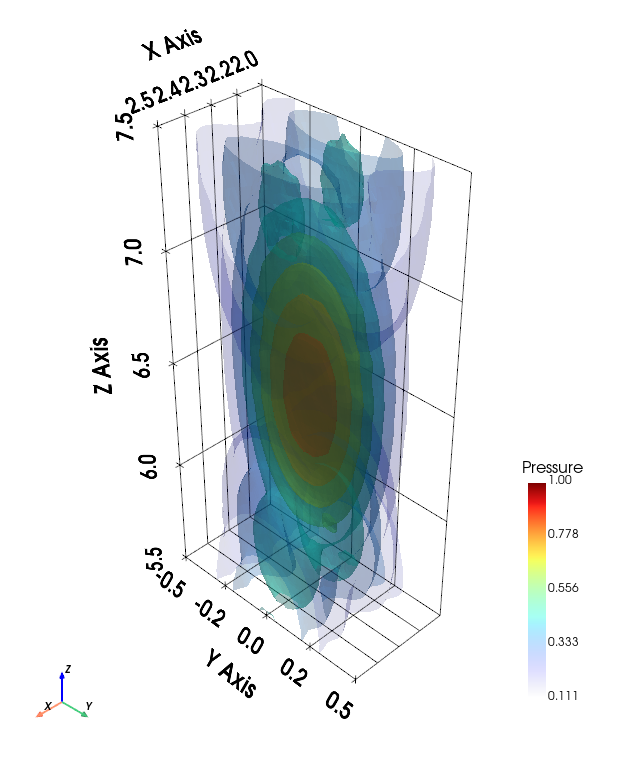

In [17]:
pressure_plotter, pressure_vol_mesh = pysonogen.plot_pressure_field(pressure_field,
                               x, y, z, notebook = True, return_mesh = True, window_size = [620, 780])

pressure_plotter.show(jupyter_backend='static')  # Add this parameter

In [18]:
TX_mesh = domino.get_mesh()

# We have already computed the mesh of the pressure field when plotting it with pysonogen functions.
# But in case we want to compute it again, we can use the following function:

# pressure_vol_mesh = pysonogen.compute_pressure_mesh(pressure_field, x, y, z)

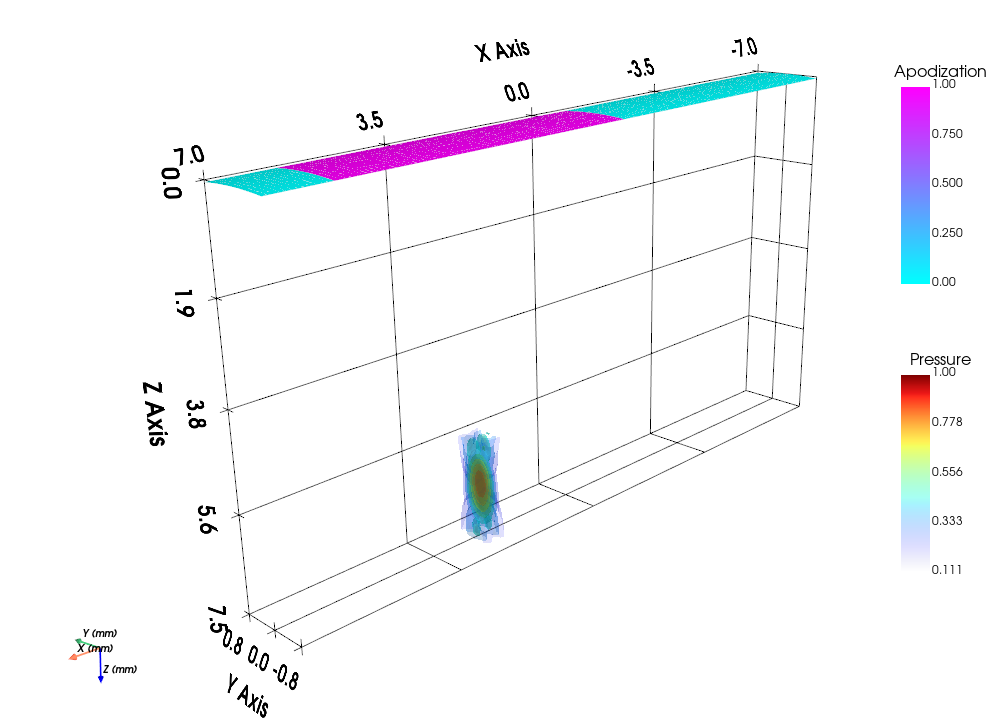

In [19]:
tx_field_plotter = pv.Plotter(window_size=[1000, 720],lighting='three lights', title=f"Transducer and pressure field.", notebook=True)

# UFO = pv.Light(position=(7.534109709672295, -4.14789440645857, 17.143688379650392), focal_point=(0, 0, 0), color='white')
tx_field_plotter = add_transducer_to_plotter(tx_field_plotter, TX_mesh)
tx_field_plotter = add_pressure_to_plotter(tx_field_plotter, pressure_vol_mesh, plot_focal_spot=False)
tx_field_plotter.add_axes(
    xlabel="X (mm)",
    ylabel="Y (mm)",
    zlabel="Z (mm)",
)
tx_field_plotter.show_grid(
    bold = True,
    n_ylabels = 3,
)
tx_field_plotter.camera.up = (0,0, -1)  # set the camera up vector to Z axis
tx_field_plotter.camera_position= [(17.648944281107863, -16.822637365183024, -4.242806948402592),
 (1.1066058920893702, 0.6284202657912669, 4.482166143887569),
 (-0.25575599294083556, 0.22734638150713718, -0.9396289133963782)]
tx_field_plotter.show(jupyter_backend='static')  # Add this parameter

In [20]:
tx_field_plotter.camera_position
tx_field_plotter.window_size

[1000, 720]

# 3. BrainGlobe

## 3.1. Check atlas disponibility

In [21]:
from brainglobe_atlasapi import BrainGlobeAtlas
from brainglobe_atlasapi import show_atlases

show_atlases()

╭───────────────────────────────── Brainglobe Atlases ─────────────────────────────────╮
│                                                                           Latest     │
│  Name                              Downloaded  Updated  Local version    version     │
│  allen_mouse_25um                      ✔          ✔          1.2           1.2       │
│  whs_sd_rat_39um                       ✔          ✔          1.2           1.2       │
│  admba_3d_e11_5_mouse_16um                                                 1.1       │
│  admba_3d_e13_5_mouse_16um                                                 1.1       │
│  admba_3d_e15_5_mouse_16um                                                 1.1       │
│  admba_3d_e18_5_mouse_16um                                                 1.1       │
│  admba_3d_p14_mouse_16.752um                                               1.1       │
│  admba_3d_p28_mouse_16.752um                                               1.1       │
│  admba_3d_p4_mouse_16.752um                                                1.1       │
│  admba_3d_p56_mouse_25um                                                   1.1       │
│  allen_cord_20um                                                           1.1       │
│  allen_human_500um                                                         1.0       │
│  allen_mouse_100um                                                         1.2       │
│  allen_mouse_10um                                                          1.2       │
│  allen_mouse_50um                                                          1.2       │
│  allen_mouse_bluebrain_barrels_1…                                          1.0       │
│  allen_mouse_bluebrain_barrels_2…                                          1.0       │
│  australian_mouse_15um                                                     1.0       │
│  azba_zfish_4um                                                            1.2       │
│  ccfv3augmented_mouse_10um                                                 1.0       │
│  ccfv3augmented_mouse_25um                                                 1.0       │
│  columbia_cuttlefish_50um                                                  1.0       │
│  csl_cat_500um                                                             1.0       │
│  drosophila_wingdisc_instar3_2um                                           0.3       │
│  eurasian_blackcap_25um                                                    1.2       │
│  example_mouse_100um                                                       1.2       │
│  kim_dev_mouse_e11-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e11-5_mri-adc_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-dwi_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-fa_31.5…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-t2_31.5…                                          1.3       │
│  kim_dev_mouse_e13-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e13-5_mri-adc_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-dwi_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-fa_34um                                           1.3       │
│  kim_dev_mouse_e13-5_mri-t2_34um                                           1.3       │
│  kim_dev_mouse_e15-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e15-5_mri-adc_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-dwi_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-fa_37.5…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-mtr_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-t2_37.5…                                          1.3    

## 3.2. Select Atlas

If the atlas is not already downloaded BrainGlobeAtlas will need internet to download atlas information.

In [22]:
bg_atlas = BrainGlobeAtlas("whs_sd_rat_39um", check_latest=False)

In [23]:
bg_atlas.metadata

{'name': 'whs_sd_rat',
 'citation': 'Kleven et al 2023, https://doi.org/10.1038/s41592-023-02034-3',
 'atlas_link': 'https://www.nitrc.org/projects/whs-sd-atlas',
 'species': 'Rattus norvegicus',
 'symmetric': False,
 'resolution': [39.0, 39.0, 39.0],
 'orientation': 'asr',
 'version': '1.2',
 'shape': [1024, 512, 512],
 'trasform_to_bg': [[0.0, -1.0, 0.0, 39936.0],
  [0.0, 0.0, -1.0, 19968.0],
  [-1.0, 0.0, 0.0, 19968.0],
  [0.0, 0.0, 0.0, 1.0]],
 'additional_references': [],
 'atlas_packager': 'Harry Carey, University of Oslo, Norway, harry.carey@medisin.uio.no'}

In [24]:
bg_atlas.space

<BGSpace AnatomicalSpace object>
origin: ('Anterior', 'Superior', 'Right')
sections: ('Frontal plane', 'Horizontal plane', 'Sagittal plane')
shape: (1024, 512, 512)

## 3.3. Select areas mesh

To see what are the areas annotations that are available for an specific atlas run the next cell

In [25]:
bg_atlas.structures

root (10000)
├── Brain (1000)
│   ├── GM (1013)
│   │   ├── Dien (1080)
│   │   │   ├── HY (1034)
│   │   │   │   └── HTh-u (48)
│   │   │   ├── PreT (1096)
│   │   │   │   ├── PRT (94)
│   │   │   │   └── Sag (163)
│   │   │   ├── Thal-D (1084)
│   │   │   │   ├── ANT (1085)
│   │   │   │   │   ├── AD (213)
│   │   │   │   │   ├── AM (254)
│   │   │   │   │   ├── AV (1086)
│   │   │   │   │   │   ├── AV-dm (214)
│   │   │   │   │   │   └── AV-vl (215)
│   │   │   │   │   ├── IAM (255)
│   │   │   │   │   ├── IMD (260)
│   │   │   │   │   ├── PIL (208)
│   │   │   │   │   ├── PT (211)
│   │   │   │   │   ├── PV (242)
│   │   │   │   │   └── SPF (278)
│   │   │   │   ├── ILM (1092)
│   │   │   │   │   ├── CL (248)
│   │   │   │   │   ├── CM (247)
│   │   │   │   │   ├── Eth (282)
│   │   │   │   │   ├── PCN (246)
│   │   │   │   │   └── PF (267)
│   │   │   │   ├── LD (1095)
│   │   │   │   │   ├── DLG (205)
│   │   │   │   │   ├── LD-dm (228)
│   │   │   │   │   └── LD-vl (229)
│   │  

In [26]:
Full_Brain_name = "root"
print(bg_atlas.structures[Full_Brain_name]['name'])

Brain_Reg_M1_name = 'M1' # Primary Motor Cortex ('M1' in rat but 'MO' in mouse)
print(bg_atlas.structures[Brain_Reg_M1_name]['name'])

Brain_Reg_SO_name   = "S1-hl"  # Primary Somatosensory Cortex (S1) - hindlimb region ("S1-hl" in rat but "SSp-ll"  in mouse)
print(bg_atlas.structures[Brain_Reg_SO_name]['name'])

Root
Primary motor area
Primary somatosensory area, hindlimb representation


## 3.4. Visualization of brain mesh

From the downloaded mesh we create the pyvista object

In [27]:
pv_Full_Brain   = pv.read(bg_atlas.structures[Full_Brain_name]['mesh_filename'])  # the entire brain surface :contentReference[oaicite:0]{index=0}
pv_Brain_Reg_M1 = pv.read(bg_atlas.structures[Brain_Reg_M1_name]['mesh_filename'])  # Primary Motor Cortex ('M1' in rat but 'MO' in mouse)
pv_Brain_Reg_SO = pv.read(bg_atlas.structures[Brain_Reg_SO_name]['mesh_filename'])  # Primary Somatosensory Cortex (S1) - hindlimb region ("S1-hl" in rat but "SSp-ll"  in mouse)

In [28]:
def plot_brain(brain_mesh, region1, region2, *, region1_name = "Region 1", region2_name = "Region 2",            
    window_size=[1280, 720], camera_position=None, notebook=True, off_screen=False,
    color1 = "permanentgreen", color2 = "cadmiumlemon", opacity1 = 0.6, opacity2 = 0.6): 
    
    brain_plotter = pv.Plotter(window_size=window_size, title=f"Rat atlas", notebook=notebook, off_screen=off_screen)
    brain_plotter.add_mesh(brain_mesh,   color="lightgrey", opacity=0.2,    label="brain")
    brain_plotter.add_mesh(region1,  color=color1,     opacity=opacity1,    label=region1_name )
    brain_plotter.add_mesh(region2,  color=color2,     opacity=opacity2,    label=region2_name )
    brain_plotter.add_axes()              # show XYZ axes
    brain_plotter.show_grid()             # show grid
    brain_plotter.add_legend(loc = 'upper left')             # show legend
    brain_plotter.camera_position = camera_position
    # # to show the plot in Jupyter Notebook
    return brain_plotter

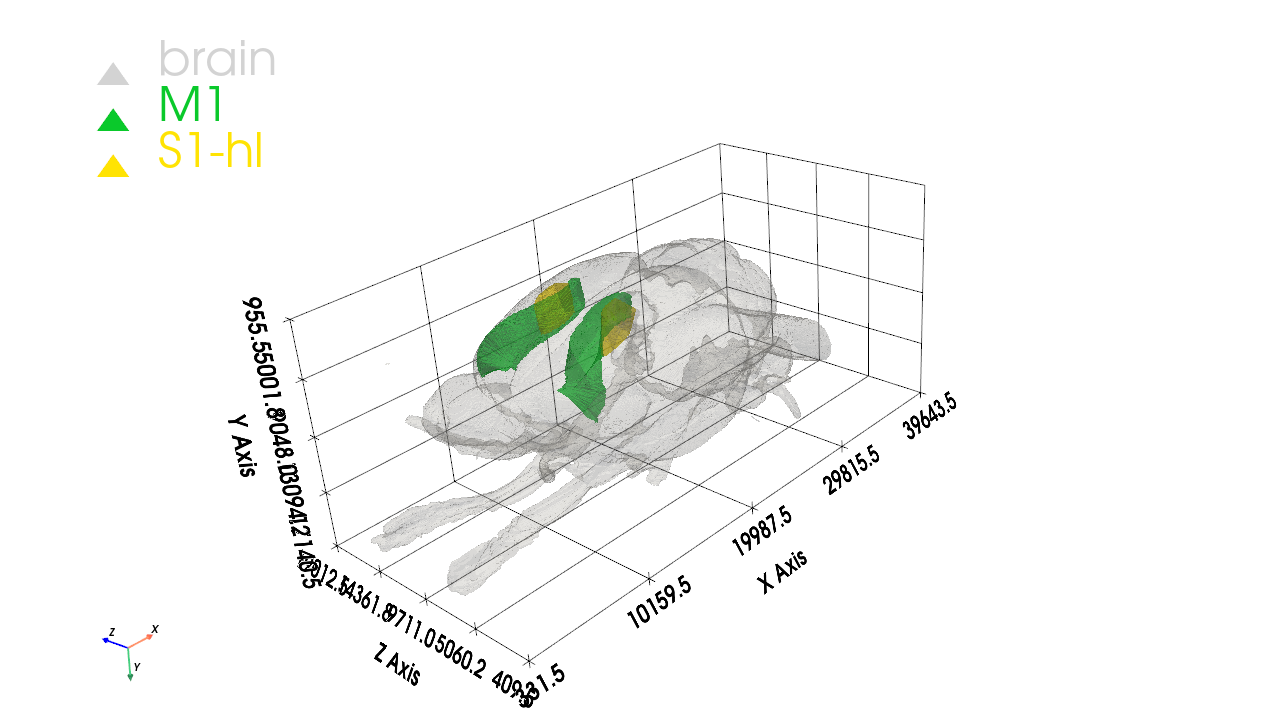

In [29]:
brain_plotter = plot_brain(pv_Full_Brain, pv_Brain_Reg_M1, pv_Brain_Reg_SO,region1_name= Brain_Reg_M1_name,region2_name= Brain_Reg_SO_name,
                           camera_position=[(-36287.07522645855, -30715.658288305676, -47985.07664367932),
                                               (19987.5, 9048.0, 9711.0),
                                                  (0.367051931123524, -0.893723057061909, 0.25793793271717014)])
brain_plotter.show(jupyter_backend='static')  # Add this parameter

# 5. Overlay Brain and Pressure field

## 5.1. Definition of spaces

When you work with a stack, the origin is the upper left corner when you show the first element stack[0, :, :] with matplotlib or when you open the stack with ImageJ. The first dimension is the one that you are slicing, the second is the height of the image, and the third is the width of the image.

If the origin of your data (first, top left voxel) is the most anterior, superior, left part of the brain, then the orientation string would be “asl” (anterior, superior, left), and you would use asr. The order of the three initials must be the same as the axis order (sliced plane, height, width).

The brain-globe atlas has its orientation in ``asr`` (origin in the Anterior-Superior-Right corner). This means the first x-axis starts in the Anterior and increases towards the Posterior orientation (on the road to cerebellum), the second y-axis stars in the Superior corner and goes towards the Inferior orientation, and the last z-axis starts in the Right and directs towards the Left orientation (pointing to the right hemisphere). 

In adition, each atlas will come with its own resolution and units. In the case of the ``whs_sd_rat_39um`` atlas, the resolution (distance between voxels) is 39um in all direction, and the shape of the stack is (1024, 512, 512) (sliced plane, height, width), which creates then in this orientation axis such us $x \in [0,  39936]\mu m$, $y \in [0,  19968]\mu m$, $x \in [0,  19968]\mu m$,

Take another look to the brain-globe information and image, to verify this information:

<BGSpace AnatomicalSpace object>
origin: ('Anterior', 'Superior', 'Right')
sections: ('Frontal plane', 'Horizontal plane', 'Sagittal plane')
shape: (1024, 512, 512)



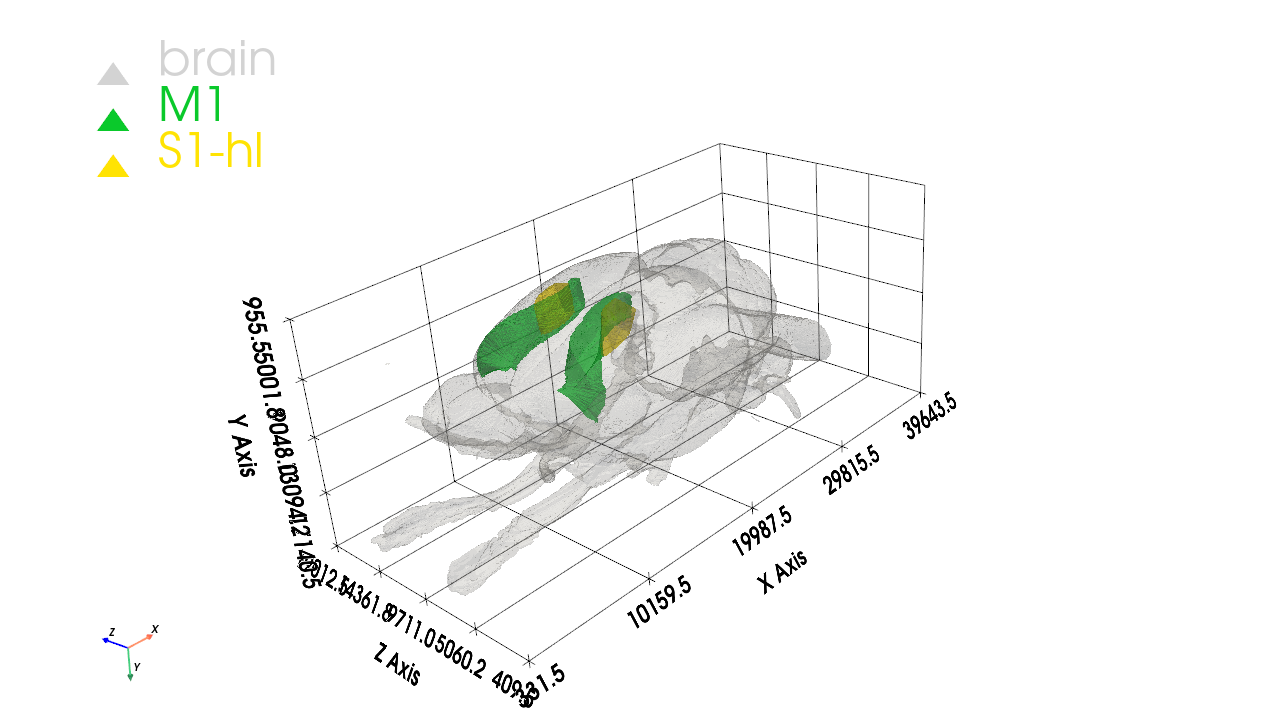

In [30]:
print(bg_atlas.space)
brain_plotter.show(jupyter_backend='static')  # Add this parameter



In our frame work we first need to change the orientation, fUS images are x vs z, and the slices will be stacked over the y direction. There for our orientation will start with the lateral information with the origin on the left hemisphere ``l``, on the most superior part ``s``, and lastly on the anterior ``a`` (front) of the brain. Therefore, our orientation would be ``lsa``. 

Brain globe counts with a module that allow us to compute affine matrix that to define the transformations one must do in a stack of data so one could change the orientation. 

In [31]:
import brainglobe_space as bg_space

In [32]:
# Now we create the target space 
target_space = bg_space.AnatomicalSpace("rps", resolution=[39*1e3, 39*1e3, 39*1e3],) # New resolution to change the units from um to mm
print(target_space)

<BGSpace AnatomicalSpace object>
origin: ('Right', 'Posterior', 'Superior')
sections: ('Sagittal plane', 'Frontal plane', 'Horizontal plane')
shape: None



From our atlas information, we can compute the matrix to go from our source space to the new target one, to then input it on our pyvista.transform() function.

In [33]:
trans_source2lsa = bg_atlas.space.transformation_matrix_to(target_space)

pv_Full_Brain_tx_space = pv_Full_Brain.copy()
pv_Full_Brain_tx_space.transform(trans_source2lsa, inplace=	True)
pv_M1_reg_tx_space = pv_Brain_Reg_M1.copy()
pv_M1_reg_tx_space.transform(trans_source2lsa, inplace=	True)
pv_SO_reg_tx_space = pv_Brain_Reg_SO.copy()
pv_SO_reg_tx_space.transform(trans_source2lsa, inplace=	True)
print(f"transformation matrix: \n {trans_source2lsa} ")


transformation matrix: 
 [[ 0.000e+00  0.000e+00  1.000e-03  0.000e+00]
 [-1.000e-03  0.000e+00  0.000e+00  1.024e+00]
 [ 0.000e+00  1.000e-03  0.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]] 


In [ ]:
plotter = plot_brain(pv_Full_Brain_tx_space, pv_M1_reg_tx_space, pv_SO_reg_tx_space,
                           region1_name= Brain_Reg_M1_name,region2_name= Brain_Reg_SO_name,
                           camera_position=[(72.90116356938879, 50.28910256335179, -28.68799842666025),
 (26.784967606806486, 0.10497755664419678, 0.3654975164772199),
 (-0.29821857288045744, -0.2579831116296196, -0.9189724679787981)],
                            notebook=False
 )

plotter.camera.up = (0,0, -1)  # set the camera up vector to Z axis
plotter.remove_bounds_axes()  # Turn off the grid
plotter.show(jupyter_backend='static')  # Add this parameter

We add tx and pressure field to plotter

In [79]:
plotter = add_transducer_to_plotter(plotter, TX_mesh)
plotter = add_pressure_to_plotter(plotter, pressure_vol_mesh, plot_focal_spot = True)
plotter.camera_position = [(65.12511139647108, 40.43427839946703, -33.931947623320745),
 (9.506395754082476, -15.281612023660273, 8.952980836109111),
 (-0.14955629417217595, -0.5050031743451957, -0.8500615911654646)]

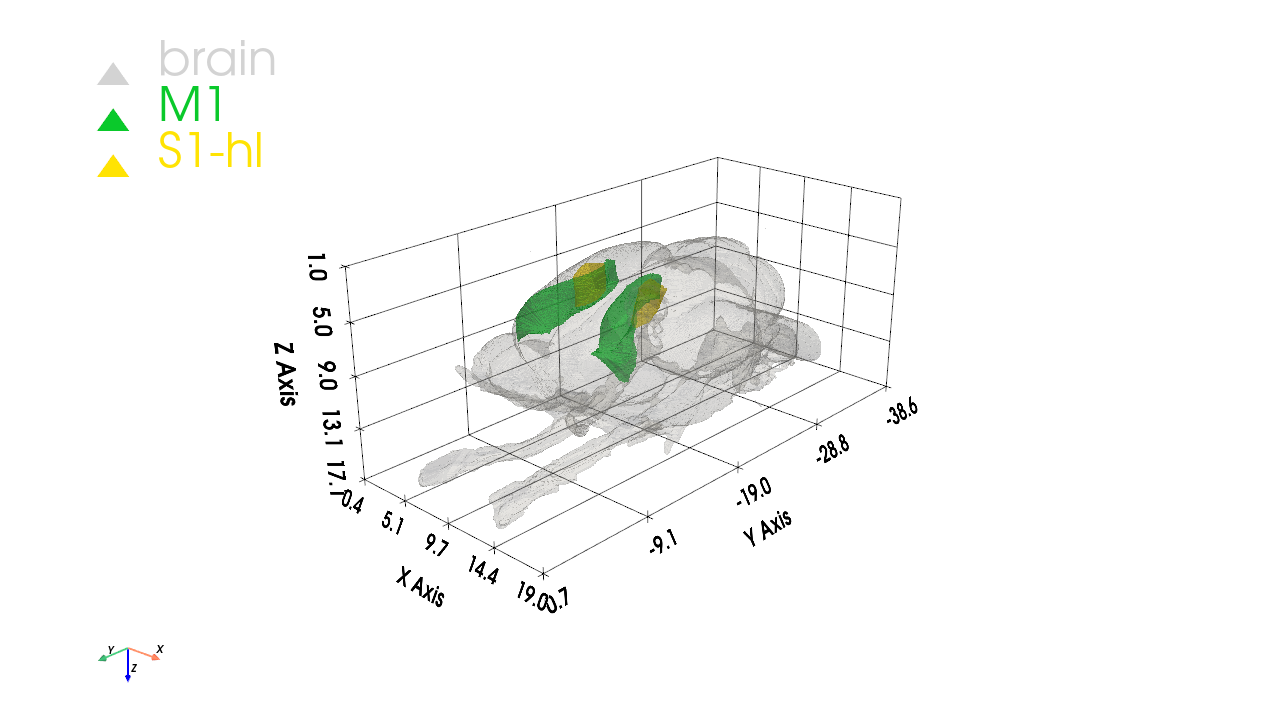

In [80]:
plotter.show(jupyter_backend="static")  # Add this parameter

Note that now both the atlas and the probe are aligned properly. But some translation to one reference frame must be chosen. We will set the x=0 and z = 0 on the center and top of the transducer repectively as we have during imaging, and the selection of the coronal plan and scaling on the brain based on the subject must be done. 

Let's supose we set the coronal plane at our zone of interest, the transducer is located 6-7mm above the brain (so we focuse at transducer elevation focus ~ 8mm), and the center of the transducer is at the center of the brain. Then,

In [81]:
# 1) We first get the center of the region mesh and move it to the origin
center_region = pv_M1_reg_tx_space.center
center_vect = np.array(center_region)
print(f"center of the brain: {center_region}")

# 3) We then place the brain region below the transducer at the desired distance
btw_tx_and_brain = 8 #mm
vertical_offset = (0,0,btw_tx_and_brain)
z_offset_vect = np.array(vertical_offset)
print(f"vertical offset: {vertical_offset}")

# 4) We then compute all translation vector
translation_vector = -center_vect + z_offset_vect

print(f"translation vector: {translation_vector}")

center of the brain: (10.373999999999999, -13.484, 5.772)
vertical offset: (0, 0, 8)
translation vector: [-10.374  13.484   2.228]


In [82]:
pv_Full_Brain_translate = pv_Full_Brain_tx_space.copy()
pv_Full_Brain_translate.translate(translation_vector, inplace=	True)
pv_M1_reg_translate = pv_M1_reg_tx_space.copy()
pv_M1_reg_translate.translate(translation_vector, inplace=	True)
pv_SO_reg_translate = pv_SO_reg_tx_space.copy()
pv_SO_reg_translate.translate(translation_vector, inplace=	True)

print(f"translation vector: {translation_vector}")

translation vector: [-10.374  13.484   2.228]


## 5.2. Final Figure

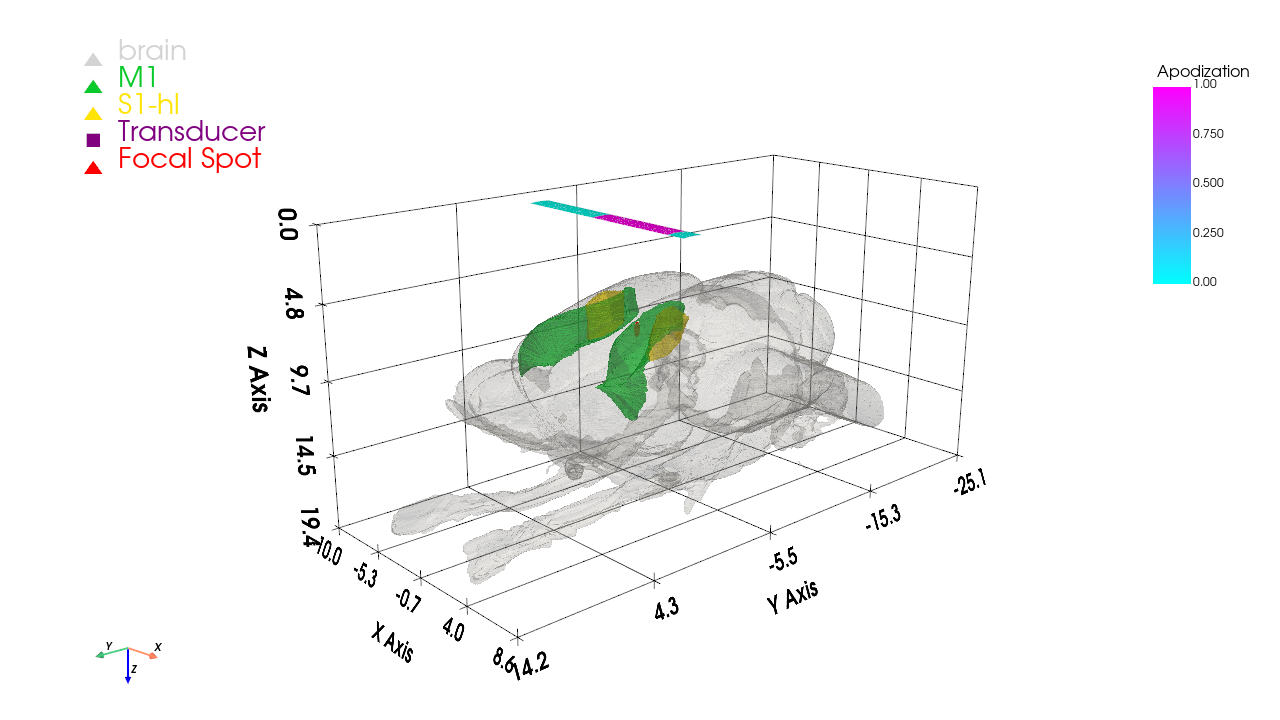

In [83]:
final_brain = plot_brain(pv_Full_Brain_translate, pv_M1_reg_translate, pv_SO_reg_translate,
                           region1_name= Brain_Reg_M1_name,region2_name= Brain_Reg_SO_name, notebook= True,
                           camera_position=[(60.226863333287426, 51.83283660351156, -16.074907119237693),
 (7.674805857873119, 4.590226600031496, 6.188799095717804),
 (-0.1728800610715033, -0.25591598557186734, -0.9511148683585453)]
 )
final_brain = add_transducer_to_plotter(final_brain, TX_mesh)
final_brain = add_pressure_to_plotter(final_brain, pressure_vol_mesh, plot_focal_spot = True)
final_brain.add_legend(loc = 'upper left')   # show legend
final_brain.camera.up = (0,0, -1)            # set the camera up vector to Z axis  
final_brain.show(jupyter_backend='static')   # Add this parameter

In [84]:
final_brain.camera_position = [(27.176052238630675, 26.86785860461294, -11.11897381216793),
 (5.769011879389099, 4.833926389460271, 4.719788692844807),
 (-0.33599925855851265, -0.31230181516574124, -0.8885786822180202)]
final_brain.show()   # Add this parameter

Widget(value='<iframe src="http://localhost:58831/index.html?ui=P_0x1f019b5e660_9&reconnect=auto" class="pyvis…

In [85]:
final_brain.camera_position

[(27.176052238630675, 26.86785860461294, -11.11897381216793),
 (5.769011879389099, 4.833926389460271, 4.719788692844807),
 (-0.33599925855851265, -0.31230181516574124, -0.8885786822180202)]

In [86]:
make_movie = False

if make_movie:

    # Create a new plotter for the video
    video_plotter = plot_brain(pv_Full_Brain_translate, pv_M1_reg_translate, pv_SO_reg_translate,
                            region1_name= Brain_Reg_M1_name,region2_name= Brain_Reg_SO_name,
                            window_size =[1280, 720], notebook= True, off_screen=True,
                            
    )
    video_plotter = add_transducer_to_plotter(video_plotter, TX_mesh)
    video_plotter = add_pressure_to_plotter(video_plotter, pressure_vol_mesh, plot_focal_spot = True)

    # Additional visual elements
    video_plotter.reset_camera_clipping_range()
    video_plotter.camera.up = (0, 0, -1)
    video_plotter.camera_position=[(19.640579914041275, 41.379030943800416, -5.760498932235443),
    (2.8987299174550767, 5.0748168946224705, 6.517957340167809),
    (0.14059219611037777, -0.3747692509763682, -0.916396116816016)]
    video_plotter.add_legend(loc = 'upper left')   # show legend

    # Render once before movie to apply camera and settings
    video_plotter.render()

    # Open movie file and define frame settings
    n_frames = 180
    video_filename = "sonogen_activation.mp4"
    video_plotter.open_movie(video_filename, framerate=20)

    # Rotation loop
    video_plotter.show(auto_close=False)

    delta_angle_deg = 360 / n_frames
    angle_deg = 0 
    for i in range(n_frames):
        angle_deg += 2
        video_plotter.camera.azimuth = angle_deg # Rotate camera
        video_plotter.render()
        video_plotter.write_frame()

    # Finalize and save
    video_plotter.close()
    print(f" Video saved to: {video_filename}")
